In [1]:
import xarray as xr
import numpy as np


ds_west = xr.open_dataset(
    "/scratch/m/m301046/west_theta_e_lam.zarr", engine="zarr",
).chunk({"time":24, "height_full":4, "cell":16384})


ds_east = xr.open_dataset(
    "/scratch/m/m301046/east_theta_e_lam.zarr", engine="zarr",
).chunk({"time":24, "height_full":4, "cell":16384})

In [ ]:
ds_west[[ "theta_e_all", "qv","ta"]].quantile([0.05, 0.5, 0.95], dim=["time", "cell"]).to_netcdf(
    "/work/mh0066/m301046/jinde_quantiles_west.nc", mode="w"
)

In [ ]:
ds_east[[ "theta_e_all", "qv","ta"]].quantile([0.05, 0.5, 0.95], dim=["time", "cell"]).to_netcdf(
    "/work/mh0066/m301046/jinde_quantiles_east.nc"
)


<xarray.Dataset> Size: 626GB
Dimensions:      (time: 1224, height_full: 56, cell: 761640)
Coordinates:
  * cell         (cell) int64 6MB 50517343 50517359 ... 125173717 125173719
    crs          int64 8B ...
  * height_full  (height_full) float64 448B 35.0 36.0 37.0 ... 88.0 89.0 90.0
    lat          (cell) float64 6MB dask.array<chunksize=(16384,), meta=np.ndarray>
    lon          (cell) float64 6MB dask.array<chunksize=(16384,), meta=np.ndarray>
  * time         (time) datetime64[ns] 10kB 2024-08-10 ... 2024-09-29T23:00:00
Data variables:
    qv           (time, height_full, cell) float32 209GB dask.array<chunksize=(24, 4, 16384), meta=np.ndarray>
    ta           (time, height_full, cell) float32 209GB dask.array<chunksize=(24, 4, 16384), meta=np.ndarray>
    theta_e_all  (time, height_full, cell) float32 209GB dask.array<chunksize=(24, 4, 16384), meta=np.ndarray>
Attributes:
    title:          ORCESTRA limited-area ICON simulations (3d)
    summary:        Limited-area ICON simulations during the ORCESTRA campaig...
    creator_name:   Romain Fiévet
    creator_email:  romain.fievet@mpimet.mpg.de
    license:        CC-BY-4.0

In [3]:
ds_east.theta_e_all.quantile([0.05, 0.5, 0.95], dim=["time", "cell"]).to_netcdf(
    "/work/mh0066/m301046/jinde_quantiles_east.nc"
)

In [4]:
grid = xr.open_dataset(
    "/work/mh0492/m301067/orcestra/auxiliary-files/grids/ORCESTRA_1250m_DOM01_vgrid.nc", 
    chunks={}
)
heights = (
    grid.where((np.rad2deg(grid.clon) > -40))
    .where((np.rad2deg(grid.clon) < -30))
    .where((np.rad2deg(grid.clat) < 10))
    .where((np.rad2deg(grid.clat) > 8))
    .mean("ncells")
)

In [3]:

ds_quantile_east = xr.open_dataset(
    "/work/mh0066/m301046/jinde_quantiles_east.nc"
)
ds_quantile_west = xr.open_dataset(
    "/work/mh0066/m301046/jinde_quantiles_west.nc"
)

In [4]:
ds_quantile_west

<xarray.Dataset> Size: 2kB
Dimensions:      (quantile: 3, height_full: 56)
Coordinates:
  * height_full  (height_full) float64 448B 35.0 36.0 37.0 ... 88.0 89.0 90.0
  * quantile     (quantile) float64 24B 0.05 0.5 0.95
Data variables:
    theta_e_all  (quantile, height_full) float64 1kB ...

In [22]:
ds_mean_east.assign_coords(quantile ="mean")

<xarray.Dataset> Size: 1kB
Dimensions:        (height_full: 56)
Coordinates:
    crs            int64 8B ...
  * height_full    (height_full) float64 448B 35.0 36.0 37.0 ... 88.0 89.0 90.0
    quantile       <U4 16B 'mean'
Data variables:
    qv             (height_full) float32 224B ...
    ta             (height_full) float32 224B ...
    theta_e_all    (height_full) float32 224B ...
    theta_e_vapor  (height_full) float32 224B ...

In [29]:
ds = xr.concat([xr.concat(
    [ds_mean_east.assign_coords(region="east", quantile="mean"), 
    ds_quantile_east.assign_coords(region="east"), 
    ],
    dim="quantile",
),
                xr.concat([
     ds_mean_west.assign_coords(region="west", quantile="mean"),
    ds_quantile_west.assign_coords(region="west")],
                          dim="quantile"
                         )
    ],
                dim="region"
).assign(
    altitude=heights.zg.sel(height_2=slice(35,90)).rename({"height_2":"height_full"})
).swap_dims({"height_full":"altitude"}).drop_vars(["theta_e_vapor"])

/tmp/ipykernel_841321/3719357383.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.concat([xr.concat(
/tmp/ipykernel_841321/3719357383.py:7: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  xr.concat([


In [30]:
ds

<xarray.Dataset> Size: 8kB
Dimensions:      (region: 2, quantile: 4, altitude: 56)
Coordinates:
    crs          int64 8B 0
    height_full  (altitude) float64 448B 35.0 36.0 37.0 38.0 ... 88.0 89.0 90.0
  * region       (region) <U4 32B 'east' 'west'
  * quantile     (quantile) <U32 512B 'mean' '0.05' '0.5' '0.95'
  * altitude     (altitude) float32 224B 1.954e+04 1.883e+04 ... 52.25 12.5
Data variables:
    qv           (region, quantile, altitude) float32 2kB 2.74e-06 ... nan
    ta           (region, quantile, altitude) float32 2kB 205.1 202.5 ... nan
    theta_e_all  (region, altitude, quantile) float64 4kB 457.1 448.9 ... 352.1

(315.3134246826172, 360.0)

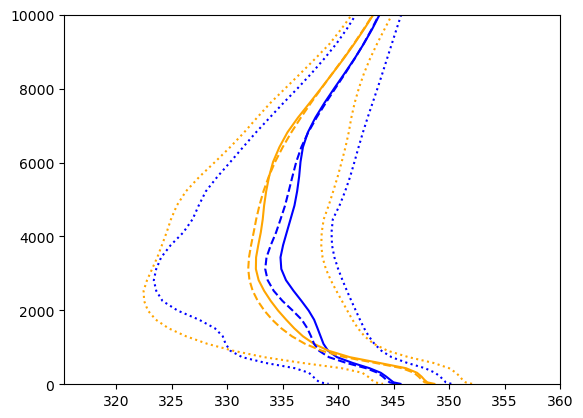

In [38]:
import matplotlib.pyplot as plt
for ls, quantile in zip([":", "-", ":", "--"],[0.05, 0.5, 0.95, "mean"]):
    for c, region in zip(["blue", "orange"],["east", "west"]):
        plt.plot(
            ds.sel(region=region, quantile=quantile).theta_e_all,
            ds.altitude,
            c=c,
            ls=ls
        )
plt.ylim(0, 10000)
plt.xlim(None, 360)

In [39]:
ds.to_netcdf(
    "/work/mh0066/m301046/theta_e_region_mean.nc"
)

sh: getfattr: command not found


In [ ]:



#%%
ds_east = xr.open_dataset(
    "/scratch/m/m301046/east_theta_e_lam.zarr", engine="zarr"
)
#%%
ds_west = xr.open_dataset(
    "/scratch/m/m301046/west_theta_e_lam.zarr", engine="zarr"
)
#%%

ds_east = xr.open_dataset(
    "/scratch/m/m301046/east_theta_e_lam.zarr", engine="zarr",
    chunks={"time":24, "cell":-1, "height_full":1}
)
ds_west = xr.open_dataset(
    "/scratch/m/m301046/west_theta_e_lam.zarr", engine="zarr",
    chunks={"time":24, "cell":-1, "height_full":1}
)
#%%
sns.set_palette("Paired")
fig, ax = plt.subplots()

ds_east.theta_e_all.mean(["cell", "time"]).plot(ax=ax, label="east full")
#ds_east.theta_e_vapor.mean(["cell", "time"]).plot(ax=ax, label="east vapor")
#ds_west.theta_e_all.mean(["cell", "time"]).plot(ax=ax, label="west full")
#ds_west.theta_e_vapor.mean(["cell", "time"]).plot(ax=ax, label="west vapor")

ax.legend()
sns.despine()

#%%

#%%

import cartopy.crs as ccrs
import cartopy.feature as cf

from easygems.resample import DelaunayResampler
from easygems.show import map_show

east_resampler = DelaunayResampler(lat=ds_east.lat, lon=ds_east.lon)
west_resampler = DelaunayResampler(lat=ds_west.lat, lon=ds_west.lon)    
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})

ax.set_extent([-60, -18, 2, 20])
ax.coastlines()

map_show(ds_east.theta_e_all.sel(height_full=90).mean("time"), resampler=east_resampler, ax=ax)

map_show(ds_west.theta_e_all.sel(height_full=90).mean("time"), resampler=west_resampler, ax=ax)

#%%

east_mean = ds_east.mean(["time", "cell"]).to_zarr(
    "/scratch/m/m301046/east_theta_e_lam_mean.zarr", mode="w"
)
west_mean = ds_west.mean(["time", "cell"]).to_zarr(
    "/scratch/m/m301046/west_theta_e_lam_mean.zarr", mode="w"
)

#%%
east_mean.theta_e_all.plot(label="east full")
west_mean.theta_e_all.plot(label="west full")
plt.legend()


#%%
import xarray as xr
east_mean = ds_east.mean(["time", "cell"]).to_zarr(
    "/scratch/m/m301046/east_theta_e_lam_mean.zarr", mode="w"
)
west_mean = ds_west.mean(["time", "cell"]).to_zarr(
    "/scratch/m/m301046/west_theta_e_lam_mean.zarr", mode="w"
)